In [1]:
import torch 
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from models.fhvae import FHVAE
from Datasets.datasets import NumpyDataset
from torch.utils.data import DataLoader


In [2]:
# Load your Transformer L2 Model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# run_name = "fhvae_timit_fbank_transformer_e1000_b256_a10.0_z32_h256_L2_H8"            
checkpoint_path = f"experiments/fhvae_timit_fbank_transformer_e1000_b256_a10.0_z32_h256_L2_H8_/best_checkpoint_best_val_lower_bound.pt"

checkpoint = torch.load(checkpoint_path, map_location=device)    

m_args = checkpoint['config']['model_args']

model = FHVAE(
    input_size=m_args['input_size'],
    z1_dim=m_args['z1_dim'],
    z2_dim=m_args['z2_dim'],
    z1_hus=m_args['z1_hus'],
    z2_hus=m_args['z2_hus'],
    x_hus=m_args['x_hus'],
    n_seqs=m_args['n_seqs'],
    n_layers=m_args['n_layers'],
    nhead=m_args['nhead']
).to(device)
   
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded checkpoint from {checkpoint_path}")


Loaded checkpoint from experiments/fhvae_timit_fbank_transformer_e1000_b256_a10.0_z32_h256_L2_H8_/best_checkpoint_best_val_lower_bound.pt


In [4]:
# Data Paths
FEAT_SCP = "/fs/scratch/PAS2301/kumar1109/TIMIT/timit_np_fbank/test/feats.scp"
LEN_SCP = "/fs/scratch/PAS2301/kumar1109/TIMIT/timit_np_fbank/test/len.scp"

test_ds = NumpyDataset(FEAT_SCP, LEN_SCP, split='test')
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

NumpyDataset: 240 out of 240 kept, min_len = 1


In [ ]:
from tqdm import tqdm

z1_list, z2_list, speaker_labels = [], [], []

print("Extracting latents from test set...")
with torch.no_grad():
    for i, (idx, x, nsegs) in enumerate(tqdm(test_loader, desc="Extracting Latents")):
        if i >= 120: break # Limit to 120 sequences
        
        if x.dim() == 4: 
            x = x.squeeze(0) # from [1, 42, 20, 80] to [42, 20, 80]

        x = x.to(device).float()
        latents = model.extract_latents(x)
        
        # Get means (mu) for z1 and z2
        z1_mu = latents['z1']['mu'].cpu().numpy()
        z2_mu = latents['z2']['mu'].cpu().numpy()
        
        # Flatten time dimension for z1 (Content is per-segment)
        if len(z1_mu.shape) == 3:
            z1_mu = z1_mu.reshape(-1, z1_mu.shape[-1])
            
        z1_list.append(z1_mu)
        z2_list.append(z2_mu) # z2 is sequence-level summary
        speaker_labels.extend([idx.item()] * z1_mu.shape[0])

# Concatenate all extracted points
z1_all = np.concatenate(z1_list, axis=0)
z2_all = np.concatenate(z2_list, axis=0)
labels = np.array(speaker_labels)

Extracting latents from test set...


Extracting Latents:  42%|████▏     | 100/240 [15:33<21:46,  9.33s/it]


In [5]:
# 5. t-SNE Analysis
print("Running t-SNE...")
tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=42)
z1_2d = tsne.fit_transform(z1_all)
z2_2d = tsne.fit_transform(z2_all)


Running t-SNE...


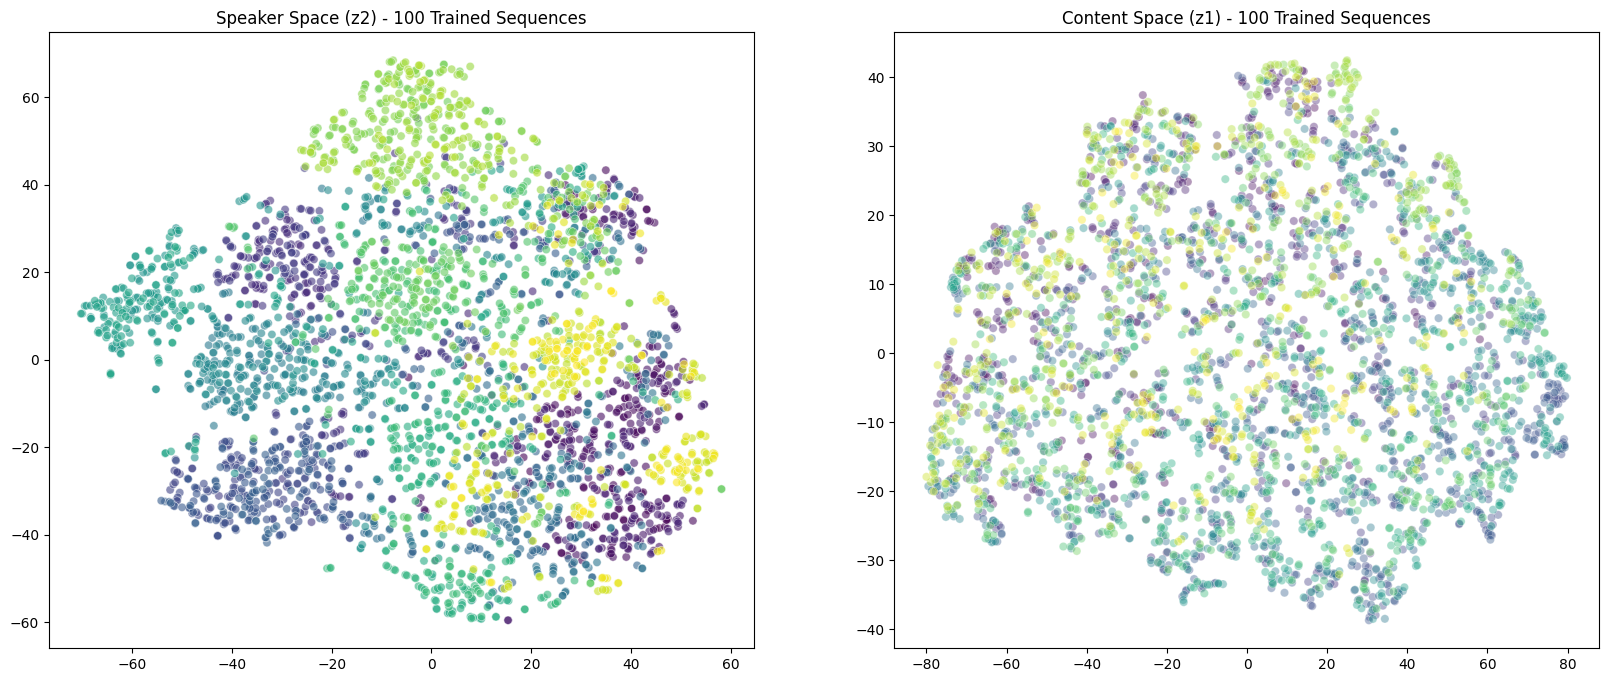

In [19]:
# # 6. Visualization
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# # Z2 Plot (Speaker Identity)
# sns.scatterplot(x=z2_2d[:,0], y=z2_2d[:,1], hue=labels, palette='tab20', ax=ax1, legend='full')
# ax1.set_title("Speaker Space (z2)")

# # Z1 Plot (Speech Content)
# sns.scatterplot(x=z1_2d[:,0], y=z1_2d[:,1], hue=labels, palette='tab20', ax=ax2, legend='full')
# ax2.set_title("Content Space (z1)")

# plt.show()

# Match labels to your 100 trained sequences
num_sequences = 100 
segments_per_seq = 42 # Based on your [42, 20, 80] shape

# Total points = 4200 (100 * 42)
# regenerate labels to ensure every segment gets the correct Sequence ID
full_labels = np.repeat(np.arange(num_sequences), segments_per_seq)

# Trim full_labels to match the exact number of points in your t-SNE array
# (This handles cases where some sequences had slightly more or fewer than 42 segments)
full_labels = full_labels[:z2_2d.shape[0]]

# 2. Final Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Z2 Speaker Space
sns.scatterplot(x=z2_2d[:,0], y=z2_2d[:,1], hue=full_labels, 
                palette='viridis', ax=ax1, legend=None, alpha=0.6)
ax1.set_title(f"Speaker Space (z2) - {num_sequences} Trained Sequences")

# Z1 Content Space
sns.scatterplot(x=z1_2d[:,0], y=z1_2d[:,1], hue=full_labels, 
                palette='viridis', ax=ax2, legend=None, alpha=0.4)
ax2.set_title(f"Content Space (z1) - {num_sequences} Trained Sequences")

plt.show()

In [13]:
print(f"Total points: {len(speaker_labels)}")
print(f"Unique label values: {np.unique(speaker_labels)}")

Total points: 3541
Unique label values: [-1]


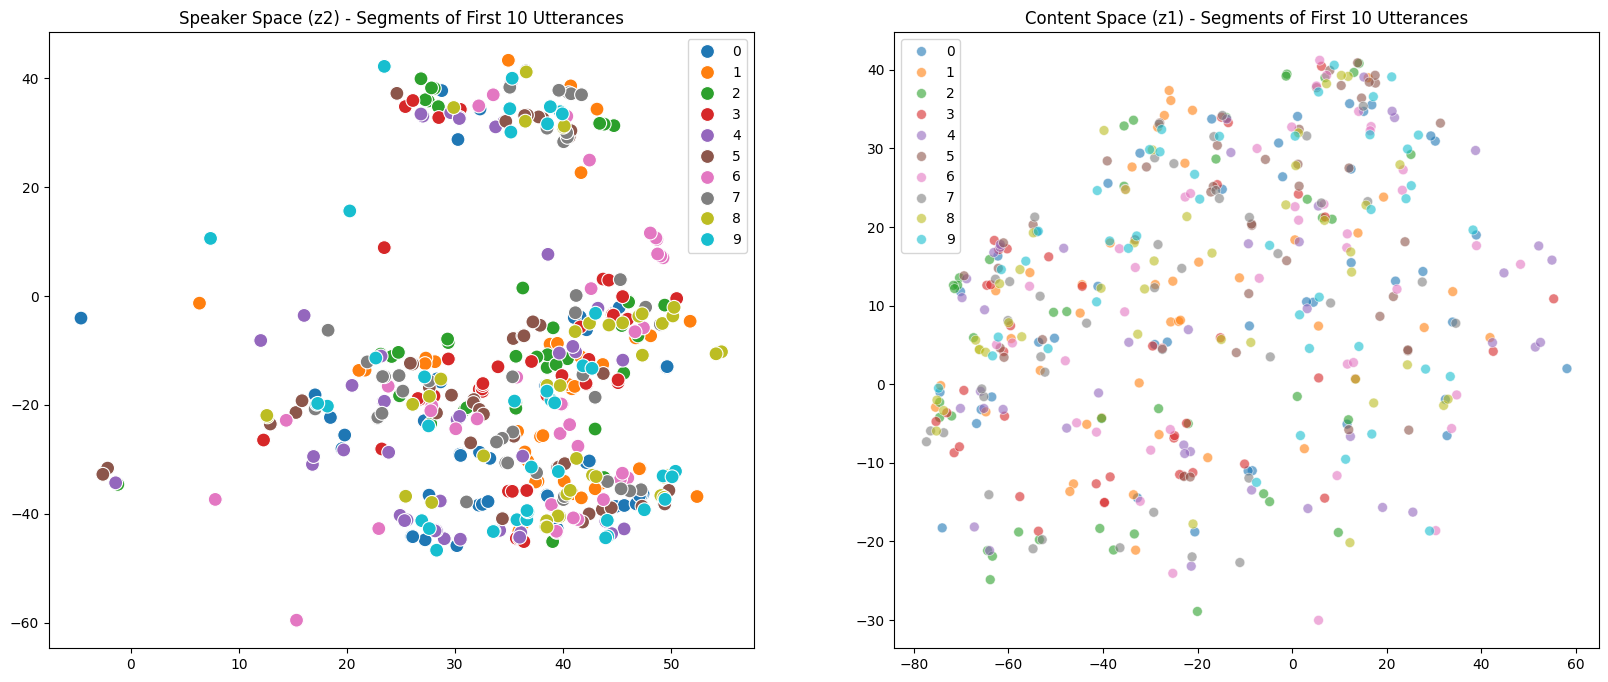

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ensure labels match the actual size of your t-SNE output (3541)
# Since we don't have the original IDs, we'll create a generic sequence ID
# that repeats for every segment.
num_total_points = z2_2d.shape[0] # This is 3541
points_per_seq = 42 # Approximate segments per utterance

# Create a label for every single point
full_labels = np.repeat(np.arange(num_total_points // points_per_seq + 1), points_per_seq)
full_labels = full_labels[:num_total_points] # Trim to exactly 3541

# 2. Define a mask that matches the 3541 size
# This filters for the first 10 "speakers" (utterances)
mask = full_labels < 10

# 3. Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Z2 Plot
sns.scatterplot(x=z2_2d[mask, 0], y=z2_2d[mask, 1], 
                hue=full_labels[mask], palette='tab10', ax=ax1, s=100)
ax1.set_title("Speaker Space (z2) - Segments of First 10 Utterances")

# Z1 Plot
sns.scatterplot(x=z1_2d[mask, 0], y=z1_2d[mask, 1], 
                hue=full_labels[mask], palette='tab10', ax=ax2, s=50, alpha=0.6)
ax2.set_title("Content Space (z1) - Segments of First 10 Utterances")

plt.show()

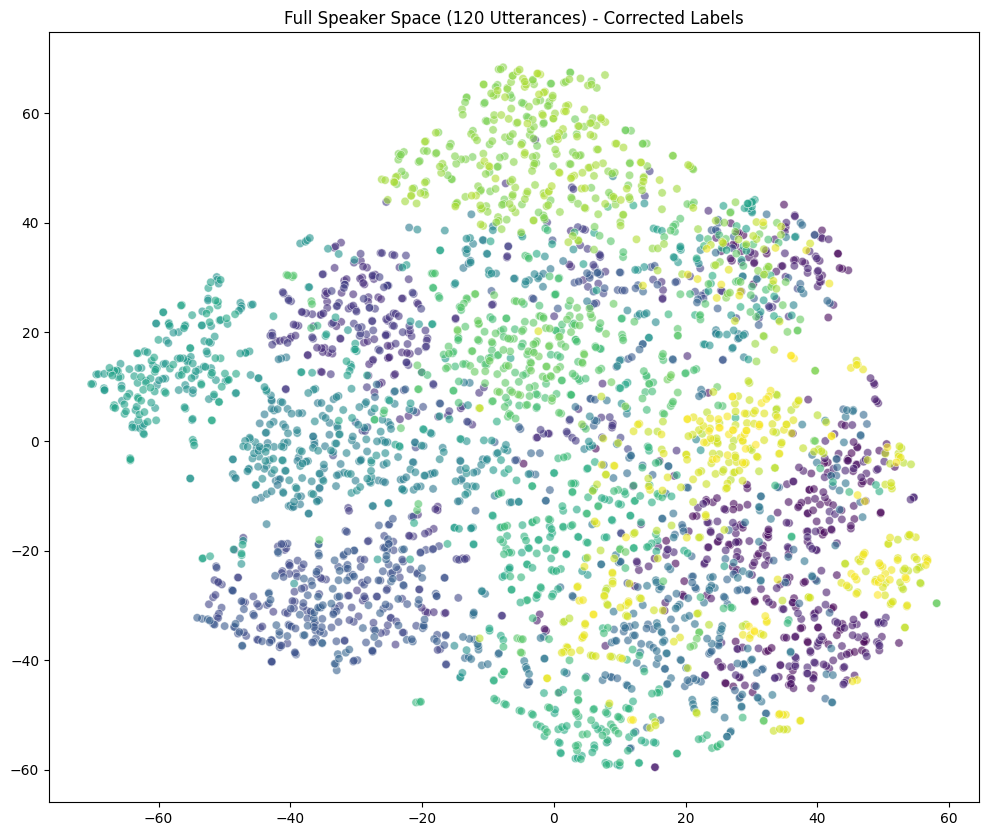

In [18]:
# Apply these to your full 120-sequence plot:
full_labels = np.repeat(np.arange(len(z2_list)), 42)[:len(z2_2d)]

plt.figure(figsize=(12, 10))
sns.scatterplot(
    x=z2_2d[:,0], 
    y=z2_2d[:,1], 
    hue=full_labels, 
    palette='viridis', # 'viridis' handles many speakers better than 'tab10'
    alpha=0.6, 
    legend=None
)
plt.title("Full Speaker Space (120 Utterances) - Corrected Labels")
plt.show()

### for lstm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# run_name = "fhvae_timit_fbank_e1000_b256_a10.0_z32_h256_LSTM2_"            
checkpoint_path = f"experiments/fhvae_timit_fbank_e1000_b256_a10.0_z32_h256_LSTM2_/best_checkpoint_best_val_lower_bound.pt"

checkpoint = torch.load(checkpoint_path, map_location=device)    

m_args = checkpoint['config']['model_args']

model_lstm = FHVAE(
    input_size=m_args['input_size'],
    z1_dim=m_args['z1_dim'],
    z2_dim=m_args['z2_dim'],
    z1_hus=m_args['z1_hus'],
    z2_hus=m_args['z2_hus'],
    x_hus=m_args['x_hus'],
    n_seqs=m_args['n_seqs'],
    n_LSTM_layers=m_args['n_LSTM_layers']
).to(device)
   
model_lstm.load_state_dict(checkpoint['model_state_dict'])
model_lstm.eval()


FHVAE(
  (mu2_table): Embedding(5560, 32)
  (z2_encoder): LatentSeqEncoder(
    (lstm): LSTM(80, 256, num_layers=2, batch_first=True)
    (z2_gauss_layer): GaussianLayer(
      (mulayer): Linear(in_features=256, out_features=32, bias=True)
      (logvar_layer): Linear(in_features=256, out_features=32, bias=True)
    )
  )
  (z1_encoder): LatentSegEncoder(
    (lstm): LSTM(112, 256, num_layers=2, batch_first=True)
    (z1_gauss_layer): GaussianLayer(
      (mulayer): Linear(in_features=256, out_features=32, bias=True)
      (logvar_layer): Linear(in_features=256, out_features=32, bias=True)
    )
  )
  (decoder): LSTMDecoder(
    (lstm): LSTM(64, 256, num_layers=2, batch_first=True)
    (dec_gauss_layer): GaussianLayer(
      (mulayer): Linear(in_features=256, out_features=80, bias=True)
      (logvar_layer): Linear(in_features=256, out_features=80, bias=True)
    )
  )
  (loss): CrossEntropyLoss()
)

In [7]:
from tqdm import tqdm

z1_list, z2_list, speaker_labels = [], [], []

print("Extracting latents from test set...")
with torch.no_grad():
    for i, (idx, x, nsegs) in enumerate(tqdm(test_loader, desc="Extracting Latents")):
        if i >= 50: break # Limit to 120 sequences
        
        if x.dim() == 4: 
            x = x.squeeze(0) # from [1, 42, 20, 80] to [42, 20, 80]

        x = x.to(device).float()
        latents = model_lstm.extract_latents(x)
        
        # Get means (mu) for z1 and z2
        z1_mu = latents['z1']['mu'].cpu().numpy()
        z2_mu = latents['z2']['mu'].cpu().numpy()
        
        # Flatten time dimension for z1 (Content is per-segment)
        if len(z1_mu.shape) == 3:
            z1_mu = z1_mu.reshape(-1, z1_mu.shape[-1])
            
        z1_list.append(z1_mu)
        z2_list.append(z2_mu) # z2 is sequence-level summary
        speaker_labels.extend([idx.item()] * z1_mu.shape[0])

# Concatenate all extracted points
z1_all = np.concatenate(z1_list, axis=0)
z2_all = np.concatenate(z2_list, axis=0)
labels = np.array(speaker_labels)

Extracting latents from test set...


Extracting Latents:  21%|██        | 50/240 [19:24<1:13:46, 23.30s/it]


In [8]:
print("Running t-SNE...")
tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=42)
z1_2d = tsne.fit_transform(z1_all)
z2_2d = tsne.fit_transform(z2_all)

Running t-SNE...


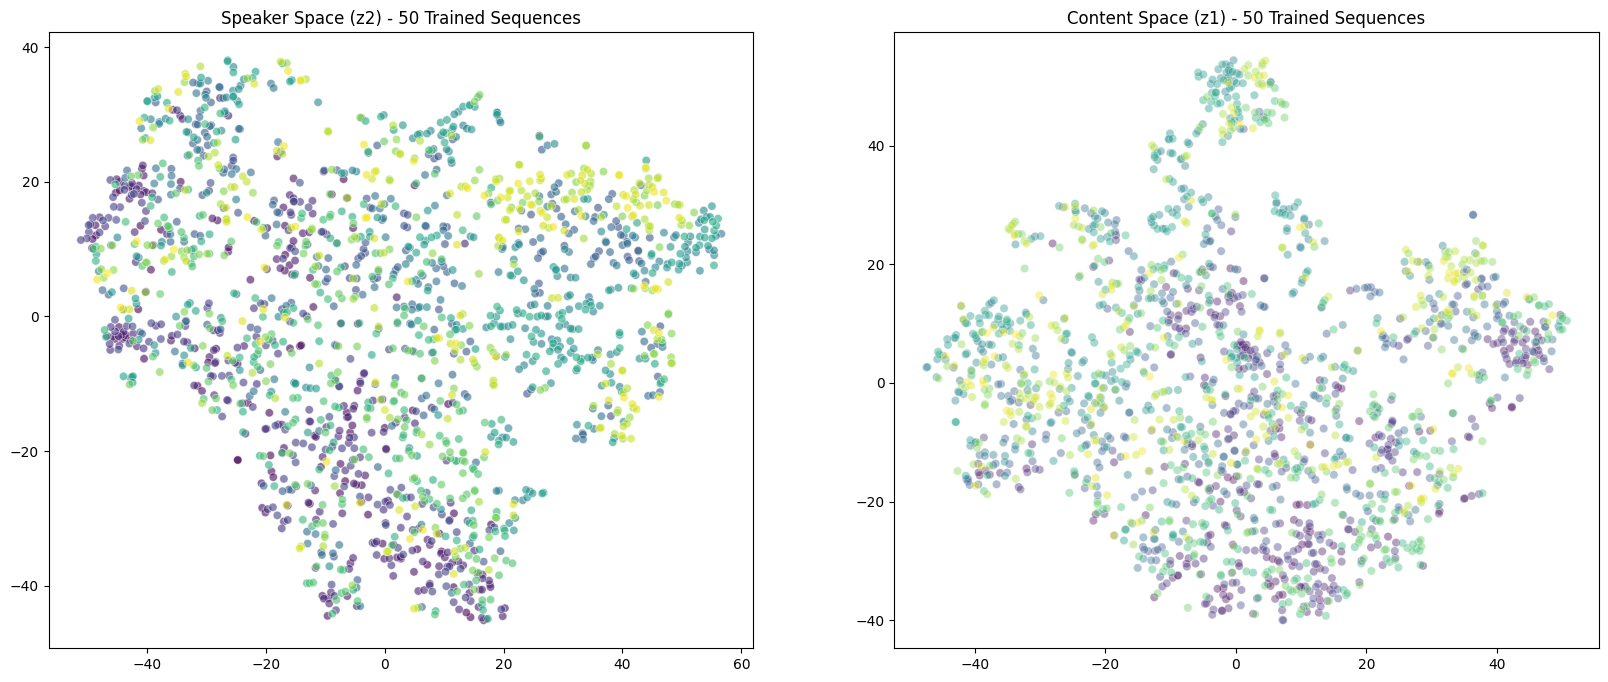

In [9]:
# Match labels to your 100 trained sequences
num_sequences = 50 
segments_per_seq = 42 # Based on your [42, 20, 80] shape

# Total points = 4200 (100 * 42)
# regenerate labels to ensure every segment gets the correct Sequence ID
full_labels = np.repeat(np.arange(num_sequences), segments_per_seq)

# Trim full_labels to match the exact number of points in your t-SNE array
# (This handles cases where some sequences had slightly more or fewer than 42 segments)
full_labels = full_labels[:z2_2d.shape[0]]

# 2. Final Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Z2 Speaker Space
sns.scatterplot(x=z2_2d[:,0], y=z2_2d[:,1], hue=full_labels, 
                palette='viridis', ax=ax1, legend=None, alpha=0.6)
ax1.set_title(f"Speaker Space (z2) - {num_sequences} Trained Sequences")

# Z1 Content Space
sns.scatterplot(x=z1_2d[:,0], y=z1_2d[:,1], hue=full_labels, 
                palette='viridis', ax=ax2, legend=None, alpha=0.4)
ax2.set_title(f"Content Space (z1) - {num_sequences} Trained Sequences")

plt.show()